# Impoliteness analysis — by party

Full-corpus LLM impoliteness scores (`gemma4:12b`, baseline prompt), by state, each
state's own ±1yr window around its AfD-entry date. Mirrors `analysis/nsc_analysis.ipynb`'s
"interjections by party" plot, but for the impoliteness classifier's output instead of
NSC interjection counts.

- **Bayern**: 2017-11–2019-10, spans the 2018-10-14 election (AfD/FDP enter).
- **Sachsen**: 2013-10–2015-09, spans the 2014-08-31 election (AfD enters, FDP+NPD exit).

In [1]:
import os

if "DATA_ROOT" not in os.environ:
    try:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv(find_dotenv())
    except ImportError:
        pass
DATA_ROOT = os.environ.get("DATA_ROOT", "")

print("DATA_ROOT:", DATA_ROOT)
assert DATA_ROOT and os.path.isdir(DATA_ROOT), f"DATA_ROOT not set or missing: {DATA_ROOT!r}"


DATA_ROOT: /Users/anna/Library/CloudStorage/GoogleDrive-anle.werner.01@gmail.com/My Drive/my_projects/M.A. Parliament/Code and Data/data


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

MEAS = Path(DATA_ROOT) / "measurement"
PROC = Path(DATA_ROOT) / "processed"


## Impoliteness scores — full Bayern run

Output of `measurement/colab_gemma.ipynb`'s full-corpus run (baseline prompt variant) →
`DATA_ROOT/measurement/impoliteness_full_by_gemma4-12b_baseline.csv`. One row per
paragraph segment; `segment_idx == -1` marks ordinary speech paragraphs (one row per
paragraph, `affiliation` = the speaker's party) as opposed to `segment_idx >= 0`, which
are `nsc` (interjection) segments carrying no party attribution in this file. For a
by-party breakdown we need the former.

In [3]:
imp = pd.read_csv(MEAS / "impoliteness_full_by_gemma4-12b_baseline.csv", parse_dates=["date"])
print(f"{len(imp):,} rows total")

# Six parties that held seats in the Bayerischer Landtag over this window
# (afd/fdp only enter after the 2018-10-14 election; frw = Freie Wähler).
PARTIES = ["csu", "spd", "grn", "fdp", "frw", "afd"]
PARTY_LABELS = {"csu": "CSU", "spd": "SPD", "grn": "GRÜNE",
                "fdp": "FDP", "frw": "Freie Wähler", "afd": "AfD"}

speech = imp[(imp["segment_idx"] == -1) & (imp["affiliation"].isin(PARTIES))].copy()
print(f"{len(speech):,} speech paragraphs across {speech['affiliation'].nunique()} parties")
print(f"Impolite rate overall: {speech['impolite'].mean()*100:.1f}%")
speech["affiliation"].value_counts()


72,089 rows total
34,346 speech paragraphs across 6 parties
Impolite rate overall: 7.9%


affiliation
csu    9986
spd    6990
grn    6864
frw    5630
afd    2740
fdp    2136
Name: count, dtype: int64

## Monthly count and share by party

- **Count**: number of paragraphs classified `impolite == True` per party per month.
- **Share**: that party's own impolite rate per month — `impolite` paragraphs / all of
  that party's paragraphs that month (%). This is the natural per-party normalization
  for a boolean label, analogous in role to the "share" panel in the NSC-by-party plot
  (there: party's share of total NSC events; here: party's own rate of the labelled
  construct).

In [4]:
import sys
from pathlib import Path

_cwd = Path(".").resolve()
_repo = _cwd if (_cwd / "utils" / "colors.py").exists() else _cwd.parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))
from utils.colors import AFFILIATION_COLORS, GOLD

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

speech["month"] = speech["date"].dt.to_period("M")

monthly_n = (
    speech.groupby(["month", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES, fill_value=0)
    .sort_index()
)

# Some months have no plenary session at all (summer recess, the ~3-week gap around
# the 2018-10-14 election before the new Landtag's 2018-11-05 constitutive session) —
# those months are simply absent from the groupby, not present-with-zero. Reindex to
# the full continuous month range so those recess months are true zero-rows: without
# this, a centred rolling window operates on row POSITION rather than calendar time,
# so a window "centred" on Sep 2018 would silently pull in Nov 2018 (the next row
# actually present) instead of the true adjacent Oct 2018 — bleeding the AfD's
# post-entry counts backward and making it look like they were active before their
# 2018-11-05 constitutive session, which the raw data rules out (AfD/FDP both show a
# hard 0 in every month before 2018-11).
full_months = pd.period_range(monthly_n.index.min(), monthly_n.index.max(), freq="M")
monthly_n = monthly_n.reindex(full_months, fill_value=0)

# First month each party actually has seats (n > 0). CSU/SPD/GRÜNE/Freie Wähler hold
# them the whole window; AfD/FDP only from the 2018-11 constitutive session on. Used
# below to blank the rolling mean before a party's true entry — a centred window still
# straddles that boundary even after the recess fix above (e.g. the window centred on
# Oct 2018 = [Sep, Oct, Nov] draws on Nov's real AfD count), which would otherwise draw
# a nonzero pre-entry line from genuine future data, not a recess artifact.
first_active = (monthly_n > 0).idxmax().apply(lambda p: p.to_timestamp())

monthly_impolite = (
    speech[speech["impolite"]].groupby(["month", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=monthly_n.index, columns=PARTIES, fill_value=0)
)
# 0/0 (recess months) -> NaN, correctly "no rate observed" rather than a fabricated 0%.
monthly_share = (monthly_impolite / monthly_n * 100)

monthly_impolite.index = monthly_impolite.index.to_timestamp()
monthly_share.index = monthly_share.index.to_timestamp()

ROLL = 3  # centred rolling window, months. Short vs. the 6-month roll in nsc_analysis
          # (~24 months of data here vs. decades there) — see markdown above for choice.
count_r = monthly_impolite.rolling(ROLL, center=True, min_periods=1)
share_r = monthly_share.rolling(ROLL, center=True, min_periods=1)

AFD_ENTRY_BY = pd.Timestamp("2018-11-05")  # from processed/afd_entry_dates.csv, state == "by"

print(f"Monthly frame: {monthly_impolite.index[0].date()} – {monthly_impolite.index[-1].date()}, "
      f"{len(monthly_impolite)} months (incl. {(monthly_n.sum(axis=1) == 0).sum()} recess months with no session)")
print("First active month per party:")
print(first_active.dt.strftime("%Y-%m").to_string())


Monthly frame: 2017-11-01 – 2019-10-01, 24 months (incl. 3 recess months with no session)
First active month per party:
affiliation
csu    2017-11
spd    2017-11
grn    2017-11
fdp    2018-11
frw    2017-11
afd    2018-11


**Monthly impolite-paragraph count and rate by party — Bayern, 2017–2019**

Two separate figures below: raw monthly values, then the 3-month centred rolling mean.
Both use the recess-reindexed monthly frame from above, so the rolling version never
blends across the Aug/Oct 2018 and Aug 2019 no-session gaps.

- **Left panel (each figure):** absolute monthly count of paragraphs classified impolite, per party.
- **Right panel (each figure):** each party's own monthly impolite rate (%) — impolite
  paragraphs / all of that party's paragraphs that month.
- Gold vertical line = 2018-11-05, the Bayerischer Landtag's constitutive session after
  the 2018-10-14 election at which the AfD (and FDP) first entered.

In [5]:
def _style_axes(ax, entry_date):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", color="#E1E0D9", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.axvline(entry_date, color=GOLD, linewidth=1.2, linestyle="--", zorder=1)


def plot_by_party(count_data, share_data, title, filename, resolution, parties, party_labels,
                   entry_date, marker=None):
    fig, (ax_cnt, ax_shr) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    fig.suptitle(title, fontsize=11, fontweight="bold", x=0.5, color="#1A1D2E")

    for ax in (ax_cnt, ax_shr):
        _style_axes(ax, entry_date)

    for party in parties:
        c     = AFFILIATION_COLORS[party]
        label = party_labels[party]
        ax_cnt.plot(count_data.index, count_data[party],
                    color=c, linewidth=1.4, marker=marker, markersize=2.5, label=label)
        ax_shr.plot(share_data.index, share_data[party],
                    color=c, linewidth=1.4, marker=marker, markersize=2.5, label=label)

    ax_cnt.set_ylabel("Impolite paragraphs (count)", fontsize=8.5, color="#5C6080")
    ax_cnt.set_title(f"{resolution} count by party", fontsize=9.5, pad=6, color="#1A1D2E")
    ax_cnt.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF", loc="upper left", ncol=2)

    ax_shr.set_ylabel("Party's own impolite rate (%)", fontsize=8.5, color="#5C6080")
    ax_shr.set_title(f"{resolution} rate by party", fontsize=9.5, pad=6, color="#1A1D2E")
    ax_shr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax_shr.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF", loc="upper left", ncol=2)

    fig.savefig(PROC / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(PROC / f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()


**Raw monthly values — no smoothing**

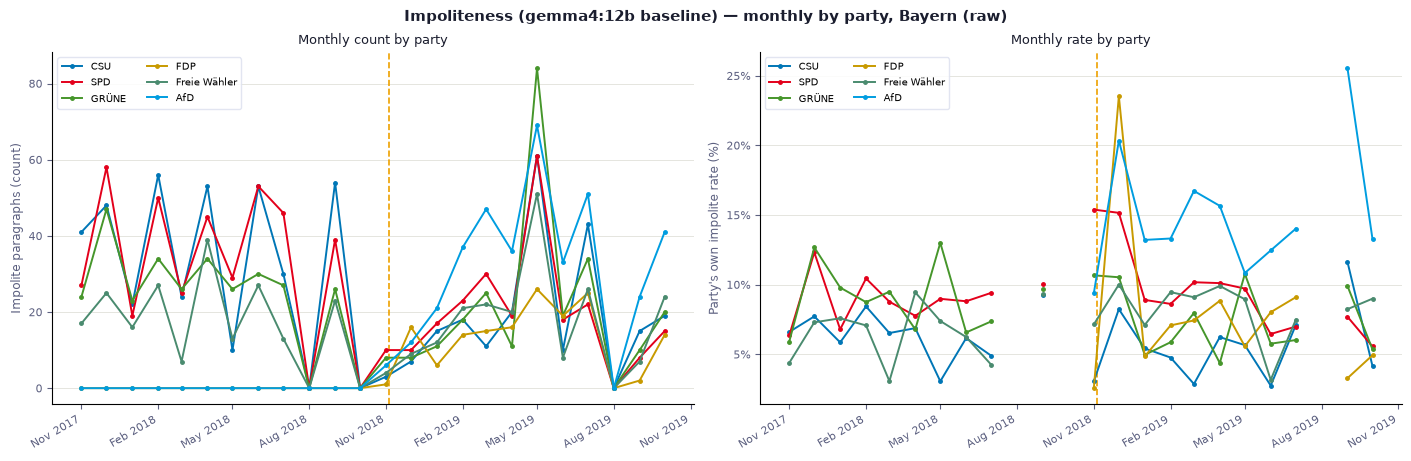

In [6]:
plot_by_party(
    monthly_impolite, monthly_share,
    title="Impoliteness (gemma4:12b baseline) — monthly by party, Bayern (raw)",
    filename="plot_impoliteness_by_party_by_raw",
    resolution="Monthly",
    parties=PARTIES, party_labels=PARTY_LABELS, entry_date=AFD_ENTRY_BY,
    marker="o",
)


**3-month centred rolling mean**

Blanked (`NaN`) before each party's own first active month — a centred window still
straddles a party's entry (e.g. the window centred on Oct 2018 draws on Nov 2018's real
AfD count) even after the recess fix, which would otherwise smooth a nonzero AfD/FDP
line into months where they held no seats at all.

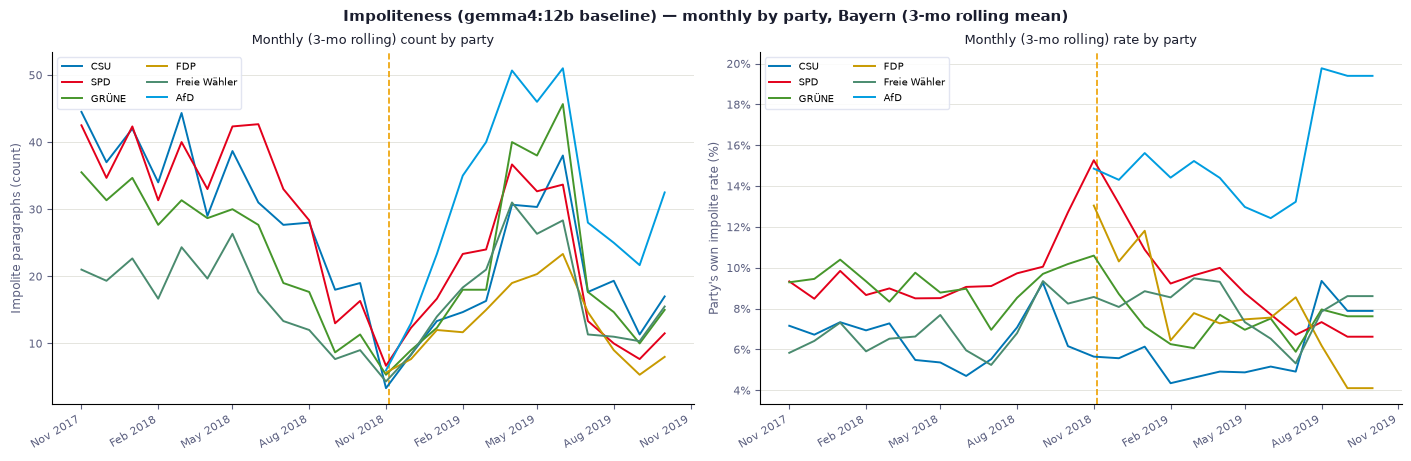

In [7]:
count_roll = count_r.mean()
share_roll = share_r.mean()
for party in PARTIES:
    _before_entry = count_roll.index < first_active[party]
    count_roll.loc[_before_entry, party] = np.nan
    share_roll.loc[_before_entry, party] = np.nan

plot_by_party(
    count_roll, share_roll,
    title="Impoliteness (gemma4:12b baseline) — monthly by party, Bayern (3-mo rolling mean)",
    filename="plot_impoliteness_by_party_by_smoothed",
    resolution="Monthly (3-mo rolling)",
    parties=PARTIES, party_labels=PARTY_LABELS, entry_date=AFD_ENTRY_BY,
)


## Other temporal resolutions

Same construction as above (recess/no-session gaps are a non-issue at these two
resolutions: per-session by definition only has points where a session happened, and
every quarter in this window contains at least one session), just grouped at a finer
and a coarser grain than "by month".

**Raw, per-session (unaggregated) — no smoothing, no monthly binning**

One point per actual Landtag sitting day (56 sessions in this window). No months are
skipped or filled — a session either happened on a given date or it didn't, so there's
nothing to reindex here.

56 distinct session dates


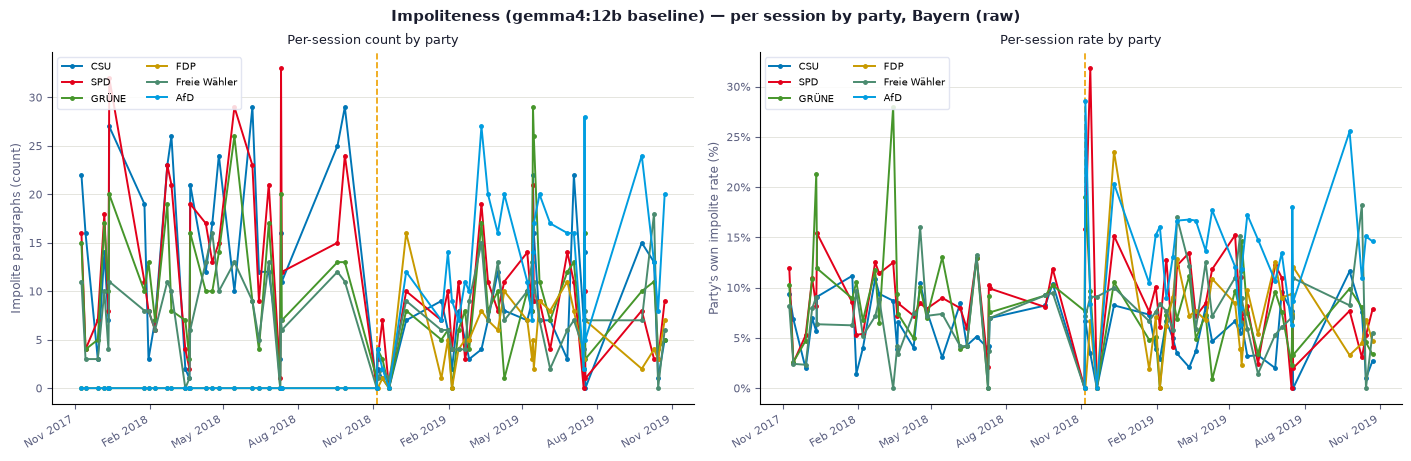

In [8]:
session_n = (
    speech.groupby(["date", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES, fill_value=0)
    .sort_index()
)
session_impolite = (
    speech[speech["impolite"]].groupby(["date", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=session_n.index, columns=PARTIES, fill_value=0)
)
session_share = (session_impolite / session_n * 100)  # 0/0 (party absent that day) -> NaN

print(f"{len(session_n)} distinct session dates")

plot_by_party(
    session_impolite, session_share,
    title="Impoliteness (gemma4:12b baseline) — per session by party, Bayern (raw)",
    filename="plot_impoliteness_by_party_by_session",
    resolution="Per-session",
    parties=PARTIES, party_labels=PARTY_LABELS, entry_date=AFD_ENTRY_BY,
    marker="o",
)


**Raw, aggregated to quarters — no smoothing**

9 quarters, 2017Q4 – 2019Q4


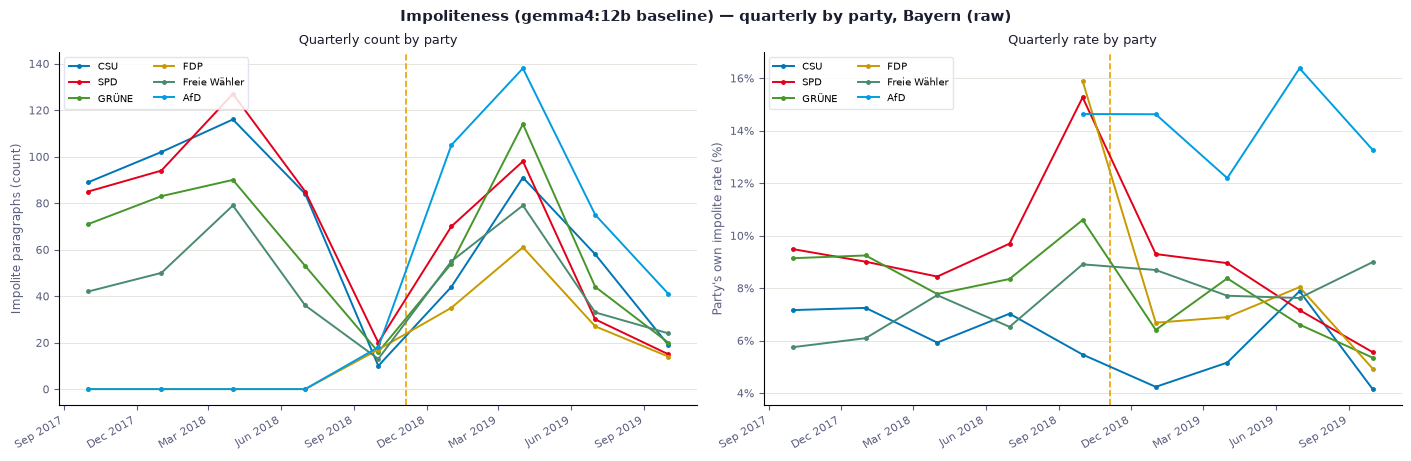

In [9]:
speech["quarter"] = speech["date"].dt.to_period("Q")

quarter_n = (
    speech.groupby(["quarter", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES, fill_value=0)
    .sort_index()
)
full_quarters = pd.period_range(quarter_n.index.min(), quarter_n.index.max(), freq="Q")
quarter_n = quarter_n.reindex(full_quarters, fill_value=0)

quarter_impolite = (
    speech[speech["impolite"]].groupby(["quarter", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=quarter_n.index, columns=PARTIES, fill_value=0)
)
quarter_share = (quarter_impolite / quarter_n * 100)

quarter_impolite.index = quarter_impolite.index.to_timestamp()
quarter_share.index = quarter_share.index.to_timestamp()

print(f"{len(quarter_n)} quarters, {quarter_n.index[0]} – {quarter_n.index[-1]}")

plot_by_party(
    quarter_impolite, quarter_share,
    title="Impoliteness (gemma4:12b baseline) — quarterly by party, Bayern (raw)",
    filename="plot_impoliteness_by_party_by_quarter",
    resolution="Quarterly",
    parties=PARTIES, party_labels=PARTY_LABELS, entry_date=AFD_ENTRY_BY,
    marker="o",
)


## Sachsen (sn)

Full-corpus LLM impoliteness scores for Sachsen, `impoliteness_full_sn_gemma4-12b_baseline.csv`
(67,114 rows, completed 2026-09-05 — local Mac run, resumed from a partial Colab run;
see conversation history). Window: 2013-10 to 2015-09, ±1yr around Sachsen's AfD entry
(2014-09-29, the 2014-08-31 Landtag election's constitutive session).

**Different transition shape than Bayern**: in Bayern, AfD and FDP simply *entered*
alongside five already-seated parties. In Sachsen, the 2014 election is a genuine
three-way replacement: **FDP and NPD both lose every seat** (last active month:
2014-07) in the **same** election that **AfD enters** (first active: 2014-09/11) — the
AfD-replaces-NPD pattern directly relevant to this project's research question. That
means the rolling-average masking fix from the Bayern section (blank the smoothed line
before a party's first active month, or a centred window bleeds its future entry
backward) now needs a mirror-image fix too: blank it *after* a party's last active
month as well, or the same bleed happens in reverse — a window centred just after
FDP/NPD's exit would blend in their real pre-exit counts, showing them as still active
after they hold zero seats.

In [10]:
imp_sn = pd.read_csv(MEAS / "impoliteness_full_sn_gemma4-12b_baseline.csv", parse_dates=["date"])
print(f"{len(imp_sn):,} rows total")

# Seven parties with real presence in the Sächsischer Landtag over this window.
# npd holds seats until the 2014-08-31 election, then none -- included because its
# exit alongside AfD's entry is directly relevant here, unlike Bayern's frw.
PARTIES_SN = ["cdu", "spd", "grn", "fdp", "lin", "npd", "afd"]
PARTY_LABELS_SN = {"cdu": "CDU", "spd": "SPD", "grn": "GRÜNE", "fdp": "FDP",
                    "lin": "LINKE", "npd": "NPD", "afd": "AfD"}

speech_sn = imp_sn[(imp_sn["segment_idx"] == -1) & (imp_sn["affiliation"].isin(PARTIES_SN))].copy()
print(f"{len(speech_sn):,} speech paragraphs across {speech_sn['affiliation'].nunique()} parties")
print(f"Impolite rate overall: {speech_sn['impolite'].mean()*100:.1f}%")
speech_sn["affiliation"].value_counts()


67,114 rows total
36,885 speech paragraphs across 7 parties
Impolite rate overall: 6.1%


affiliation
cdu    8978
lin    8287
grn    5916
spd    5534
fdp    3045
npd    2695
afd    2430
Name: count, dtype: int64

**Monthly count and share by party — Sachsen**

Same construction as the Bayern section: recess-months reindexed to true zero-rows
before rolling, and the rolling mean blanked outside each party's own active span
(now front *and* back, per the note above) rather than just before entry.

In [11]:
speech_sn["month"] = speech_sn["date"].dt.to_period("M")

monthly_n_sn = (
    speech_sn.groupby(["month", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES_SN, fill_value=0)
    .sort_index()
)

full_months_sn = pd.period_range(monthly_n_sn.index.min(), monthly_n_sn.index.max(), freq="M")
monthly_n_sn = monthly_n_sn.reindex(full_months_sn, fill_value=0)

# First AND last month each party actually has seats (n > 0). CDU/SPD/GRÜNE/LINKE hold
# them the whole window; AfD only from 2014-09/11 on; FDP/NPD only up to 2014-07 (both
# lose every seat in the 2014-08-31 election AfD enters via). Used below to blank the
# rolling mean outside a party's true active span -- a centred window still bleeds
# across either boundary even after the recess-month reindex above.
first_active_sn = (monthly_n_sn > 0).idxmax().apply(lambda p: p.to_timestamp())
last_active_sn = (
    monthly_n_sn.apply(lambda col: col[col > 0].index.max()).apply(lambda p: p.to_timestamp())
)

monthly_impolite_sn = (
    speech_sn[speech_sn["impolite"]].groupby(["month", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=monthly_n_sn.index, columns=PARTIES_SN, fill_value=0)
)
monthly_share_sn = (monthly_impolite_sn / monthly_n_sn * 100)

monthly_impolite_sn.index = monthly_impolite_sn.index.to_timestamp()
monthly_share_sn.index = monthly_share_sn.index.to_timestamp()

count_r_sn = monthly_impolite_sn.rolling(ROLL, center=True, min_periods=1)
share_r_sn = monthly_share_sn.rolling(ROLL, center=True, min_periods=1)

AFD_ENTRY_SN = pd.Timestamp("2014-09-29")  # from processed/afd_entry_dates.csv, state == "sn"

print(f"Monthly frame: {monthly_impolite_sn.index[0].date()} – {monthly_impolite_sn.index[-1].date()}, "
      f"{len(monthly_impolite_sn)} months (incl. {(monthly_n_sn.sum(axis=1) == 0).sum()} recess months)")
print("First / last active month per party:")
print(pd.DataFrame({"first": first_active_sn.dt.strftime("%Y-%m"),
                     "last": last_active_sn.dt.strftime("%Y-%m")}).to_string())


Monthly frame: 2013-10-01 – 2015-09-01, 24 months (incl. 5 recess months)
First / last active month per party:
               first     last
affiliation                  
cdu          2013-10  2015-09
spd          2013-10  2015-09
grn          2013-10  2015-09
fdp          2013-10  2014-07
lin          2013-10  2015-09
npd          2013-10  2014-07
afd          2014-09  2015-09


**Raw monthly values — no smoothing**

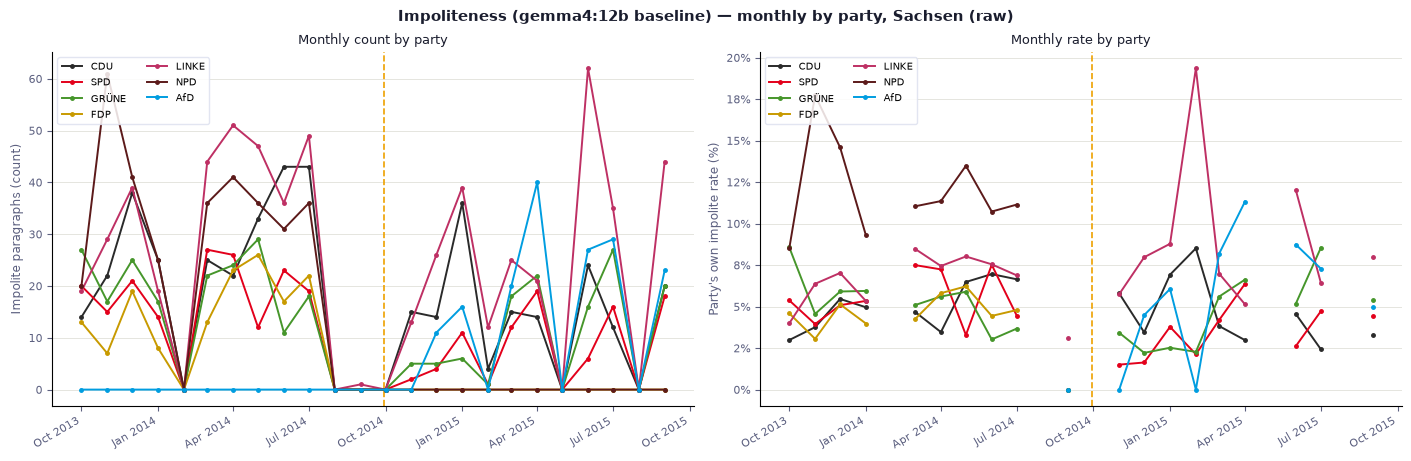

In [12]:
plot_by_party(
    monthly_impolite_sn, monthly_share_sn,
    title="Impoliteness (gemma4:12b baseline) — monthly by party, Sachsen (raw)",
    filename="plot_impoliteness_by_party_sn_raw",
    resolution="Monthly",
    parties=PARTIES_SN, party_labels=PARTY_LABELS_SN, entry_date=AFD_ENTRY_SN,
    marker="o",
)


**3-month centred rolling mean**

Blanked outside each party's [first_active, last_active] span -- front-masked for AfD
(enters mid-window), back-masked for FDP/NPD (exit mid-window), no masking for the
four parties present the whole time.

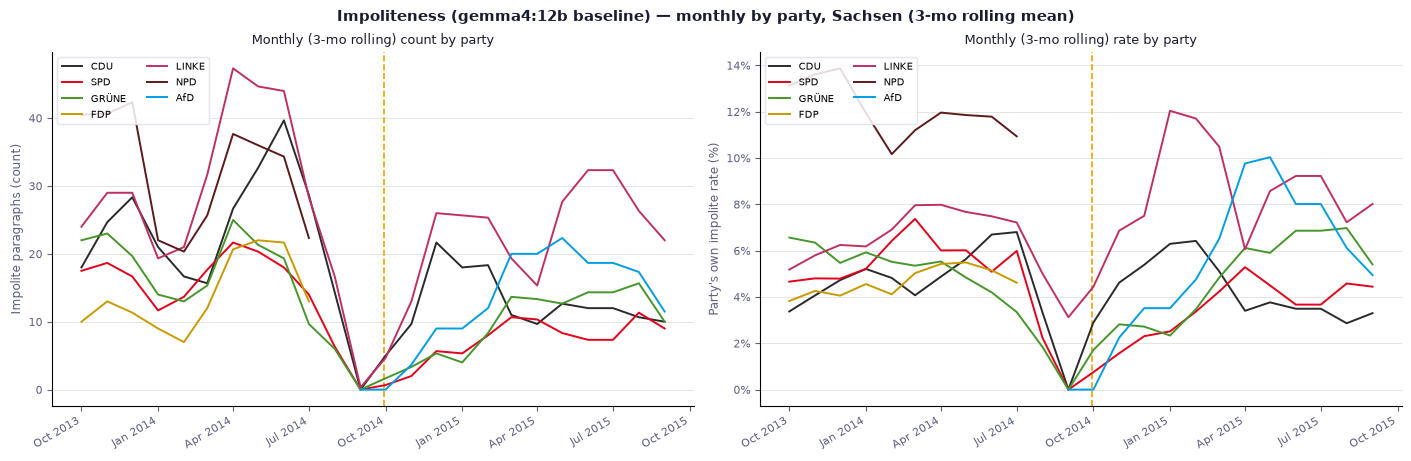

In [13]:
count_roll_sn = count_r_sn.mean()
share_roll_sn = share_r_sn.mean()
for party in PARTIES_SN:
    _outside_span = (
        (count_roll_sn.index < first_active_sn[party]) |
        (count_roll_sn.index > last_active_sn[party])
    )
    count_roll_sn.loc[_outside_span, party] = np.nan
    share_roll_sn.loc[_outside_span, party] = np.nan

plot_by_party(
    count_roll_sn, share_roll_sn,
    title="Impoliteness (gemma4:12b baseline) — monthly by party, Sachsen (3-mo rolling mean)",
    filename="plot_impoliteness_by_party_sn_smoothed",
    resolution="Monthly (3-mo rolling)",
    parties=PARTIES_SN, party_labels=PARTY_LABELS_SN, entry_date=AFD_ENTRY_SN,
)


**Raw, per-session (unaggregated) — no smoothing, no monthly binning**

37 distinct session dates


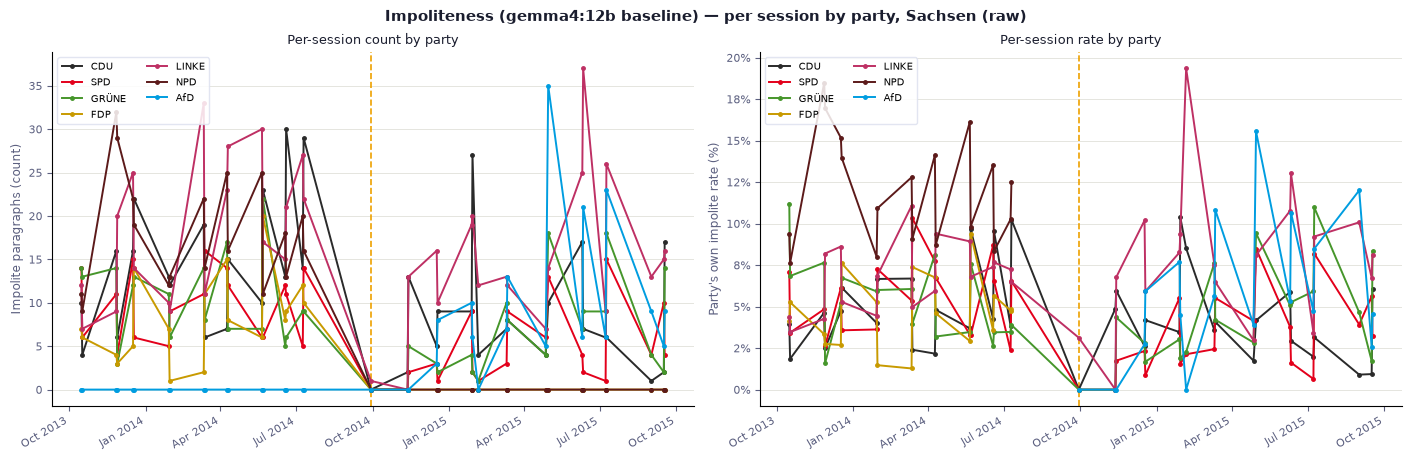

In [14]:
session_n_sn = (
    speech_sn.groupby(["date", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES_SN, fill_value=0)
    .sort_index()
)
session_impolite_sn = (
    speech_sn[speech_sn["impolite"]].groupby(["date", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=session_n_sn.index, columns=PARTIES_SN, fill_value=0)
)
session_share_sn = (session_impolite_sn / session_n_sn * 100)

print(f"{len(session_n_sn)} distinct session dates")

plot_by_party(
    session_impolite_sn, session_share_sn,
    title="Impoliteness (gemma4:12b baseline) — per session by party, Sachsen (raw)",
    filename="plot_impoliteness_by_party_sn_session",
    resolution="Per-session",
    parties=PARTIES_SN, party_labels=PARTY_LABELS_SN, entry_date=AFD_ENTRY_SN,
    marker="o",
)


**Raw, aggregated to quarters — no smoothing**

8 quarters, 2013Q4 – 2015Q3


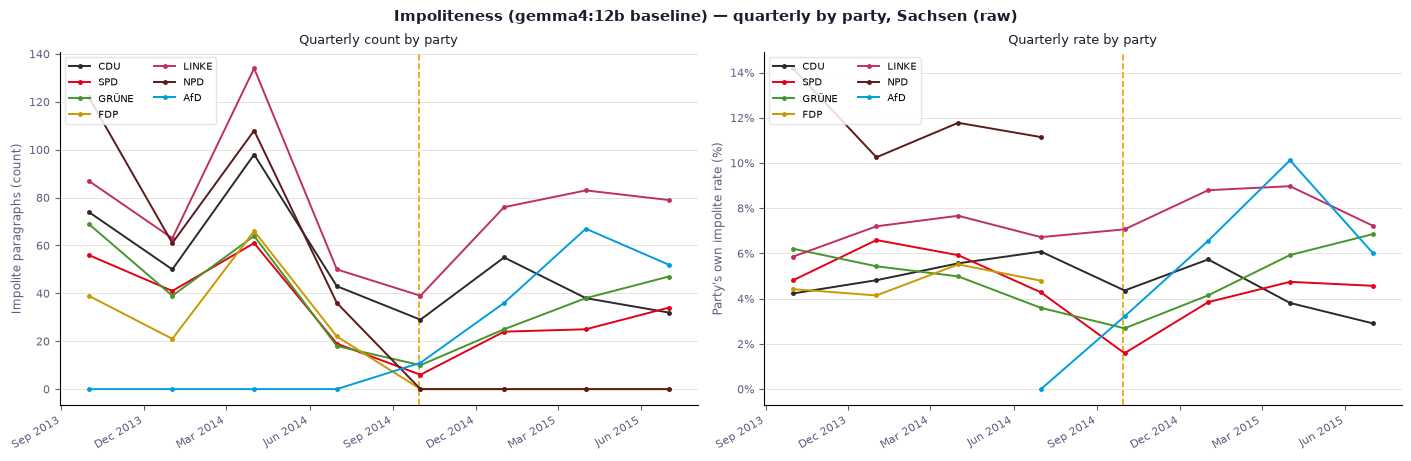

In [15]:
speech_sn["quarter"] = speech_sn["date"].dt.to_period("Q")

quarter_n_sn = (
    speech_sn.groupby(["quarter", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(columns=PARTIES_SN, fill_value=0)
    .sort_index()
)
full_quarters_sn = pd.period_range(quarter_n_sn.index.min(), quarter_n_sn.index.max(), freq="Q")
quarter_n_sn = quarter_n_sn.reindex(full_quarters_sn, fill_value=0)

quarter_impolite_sn = (
    speech_sn[speech_sn["impolite"]].groupby(["quarter", "affiliation"]).size()
    .unstack("affiliation", fill_value=0)
    .reindex(index=quarter_n_sn.index, columns=PARTIES_SN, fill_value=0)
)
quarter_share_sn = (quarter_impolite_sn / quarter_n_sn * 100)

quarter_impolite_sn.index = quarter_impolite_sn.index.to_timestamp()
quarter_share_sn.index = quarter_share_sn.index.to_timestamp()

print(f"{len(quarter_n_sn)} quarters, {quarter_n_sn.index[0]} – {quarter_n_sn.index[-1]}")

plot_by_party(
    quarter_impolite_sn, quarter_share_sn,
    title="Impoliteness (gemma4:12b baseline) — quarterly by party, Sachsen (raw)",
    filename="plot_impoliteness_by_party_sn_quarter",
    resolution="Quarterly",
    parties=PARTIES_SN, party_labels=PARTY_LABELS_SN, entry_date=AFD_ENTRY_SN,
    marker="o",
)
